In [3]:
import pandas as pd

df = pd.read_csv("Housing.csv")

In [4]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [5]:
df.shape

(545, 13)

In [6]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [8]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [9]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [11]:
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

KeyError: "None of [Index(['furnishingstatus'], dtype='object')] are in the [columns]"

In [12]:
df.columns


Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus_semi-furnished',
       'furnishingstatus_unfurnished'],
      dtype='object')

In [13]:
X = df.drop('price', axis=1)
y = df['price']

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

ValueError: could not convert string to float: 'yes'

In [16]:
X.select_dtypes(include='object').columns

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea'],
      dtype='object')

In [17]:
df['mainroad'].unique()

array(['yes', 'no'], dtype=object)

In [18]:
cols = ['mainroad', 'guestroom', 'basement',
        'hotwaterheating', 'airconditioning', 'prefarea']

for col in cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

In [19]:
X = df.drop('price', axis=1)
y = df['price']

In [20]:
X.select_dtypes(include='object').columns

Index([], dtype='object')

In [21]:
X = df.drop('price', axis=1)
y = df['price']

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [24]:
y_pred = model.predict(X_test)

In [25]:
from sklearn.metrics import r2_score

score = r2_score(y_test, y_pred)
print(score)

0.6529242642153185


In [26]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
print(mae)

970043.4039201637


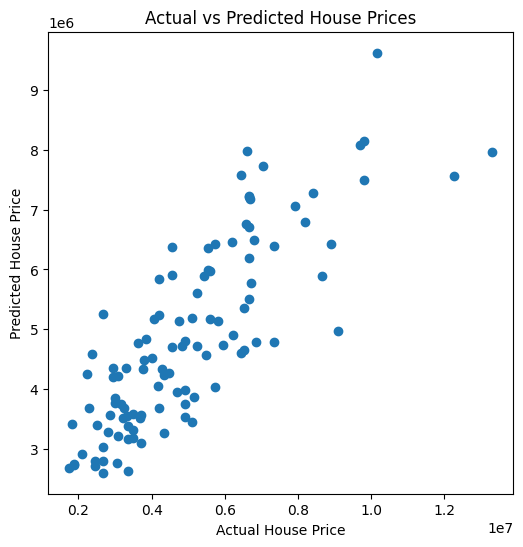

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

In [28]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

importance = importance.sort_values(by='Coefficient', ascending=False)
print(importance)

                            Feature   Coefficient
2                         bathrooms  1.094445e+06
8                   airconditioning  7.914267e+05
7                   hotwaterheating  6.846499e+05
10                         prefarea  6.298906e+05
3                           stories  4.074766e+05
6                          basement  3.902512e+05
4                          mainroad  3.679199e+05
5                         guestroom  2.316100e+05
9                           parking  2.248419e+05
1                          bedrooms  7.677870e+04
0                              area  2.359688e+02
11  furnishingstatus_semi-furnished -1.268818e+05
12     furnishingstatus_unfurnished -4.136451e+05


# House Price Prediction using Linear Regression




## Objective

The objective of this project is to predict house prices using Linear Regression. This model learns the relationship between house features and house prices to predict the price of new houses.

import pandas as pd

df = pd.read_csv("Housing.csv")

## Exploratory Data Analysis (EDA)

In this step, we explore the dataset to understand its structure, columns, data types, and statistical information before training the model.

df.head()

df.shape

df.columns

df.info()

df.describe()

## Data Preprocessing

In this step, missing values are checked and categorical data is converted into numerical format because machine learning models work with numerical data.

df.isnull.sum()

## Feature Selection

The target variable is **price** and the remaining columns are used as features for prediction.

X = df.drop('price', axis=1)
y = df['price']

## Train-Test Split

The dataset is divided into training data (80%) and testing data (20%). The training data is used to train the model, while the testing data is used to evaluate its performance.

## Model Training

A Linear Regression model is trained using the training dataset.

model = LinearRegression()
model.fit(X_train, y_train)

## Prediction

The trained model is used to predict house prices for the testing dataset.

y_pred = model.predict(X_test)

## Model Evaluation

The model is evaluated using R² Score and Mean Absolute Error (MAE).

print(score)
print(mae)

## Conclusion

This project successfully predicts house prices using Linear Regression.

### Results

- R² Score: 0.653
- MAE: 970043.40

The model achieved reasonable prediction performance and demonstrated the complete machine learning workflow, including data preprocessing, feature engineering, model training, prediction, and evaluation.